In [8]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"
import keras
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np


In [9]:
tf.random.set_seed(42)

In [10]:
data_dir = r"/content/drive/MyDrive/concave"
image_size = (256,256)
batch_size = 256

print("Loading dataset from:", data_dir)

Loading dataset from: /content/drive/MyDrive/concave


In [11]:
raw_train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=image_size,
    batch_size=batch_size,
)

raw_val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=image_size,
    batch_size=batch_size,
)


class_names = raw_train_ds.class_names
print("Detected classes:", class_names)

Found 900 files belonging to 6 classes.
Using 720 files for training.
Found 900 files belonging to 6 classes.
Using 180 files for validation.
Detected classes: ['Moon_jellyfish', 'barrel_jellyfish', 'blue_jellyfish', 'compass_jellyfish', 'lions_mane_jellyfish', 'mauve_stinger_jellyfish']


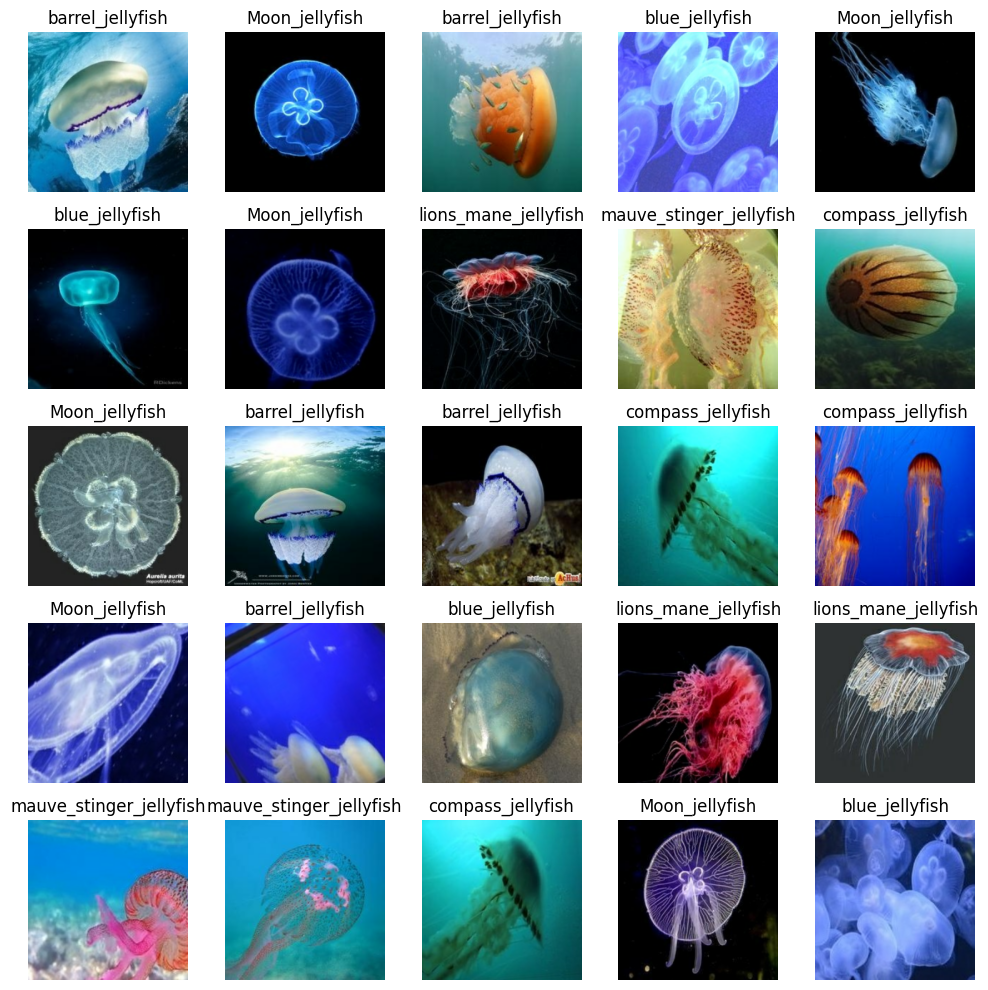

In [12]:
normalization_layer = tf.keras.layers.Rescaling(1.0 / 255)
train_ds = raw_train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = raw_val_ds.map(lambda x, y: (normalization_layer(x), y))


plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(25):
        plt.subplot(5, 5, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")
plt.tight_layout()
plt.show()


In [13]:
conv_model = keras.Sequential(
    [
        keras.layers.Conv2D(32, (3, 3), input_shape=(256,256, 3), padding="same"),
        keras.layers.ReLU(name="relu1"),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Conv2D(64, (3, 3), padding="same"),
        keras.layers.ReLU(name="relu2"),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Conv2D(64, (3, 3), padding="same"),
        keras.layers.ReLU(name="relu3"),
        keras.layers.Flatten(),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(10),
    ]
)

In [14]:
print("compiling the convolution model...")
conv_model.compile(
    optimizer="adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

# Train the model.
print("conv model training...")
conv_hist = conv_model.fit(train_ds, epochs=20, validation_data=val_ds)


compiling the convolution model...
conv model training...
Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 62s 16s/step - accuracy: 0.1119 - loss: 4.7170 - val_accuracy: 0.1889 - val_loss: 3.6557
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.1762 - loss: 3.3393 - val_accuracy: 0.2500 - val_loss: 2.0168
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.2330 - loss: 2.0256 - val_accuracy: 0.3111 - val_loss: 1.7271
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.3786 - loss: 1.6336 - val_accuracy: 0.2722 - val_loss: 1.7254
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.3785 - loss: 1.4807 - val_accuracy: 0.4333 - val_loss: 1.4450
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.4413 - loss: 1.3847 - val_accuracy: 0.3500 - val_loss: 1.4665
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.5498 - loss: 1.2169 - val_accuracy: 0.5000 - val_loss: 1.2404
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.6062 - loss: 1.100

In [15]:
conv_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (ReLU)                    │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (ReLU)                    │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3 (ReLU)                    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 262144)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │    16,777,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,502,752 (192.65 MB)

 Trainable params: 16,834,250 (64.22 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 33,668,502 (128.44 MB)

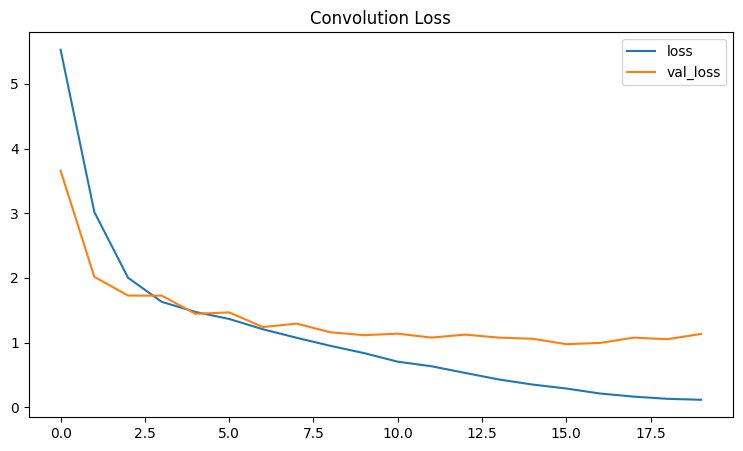

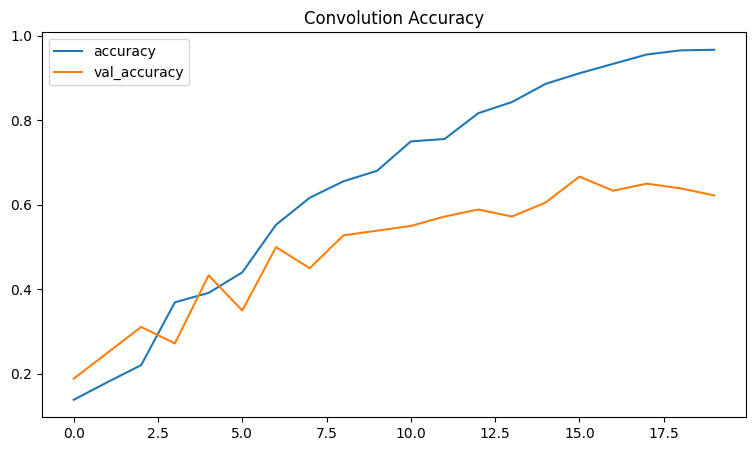

In [27]:
plt.figure(figsize=(20, 5))

plt.subplot(1, 2, 1)
plt.title("Convolution Loss")
plt.plot(conv_hist.history["loss"], label="loss")
plt.plot(conv_hist.history["val_loss"], label="val_loss")
plt.legend()


plt.show()

plt.figure(figsize=(20, 5))

plt.subplot(1, 2, 1)
plt.title("Convolution Accuracy")
plt.plot(conv_hist.history["accuracy"], label="accuracy")
plt.plot(conv_hist.history["val_accuracy"], label="val_accuracy")
plt.legend()

plt.show()

In [29]:
print("Final Convolutional Model Accuracy:")
print(f"Training Accuracy: {conv_hist.history['accuracy'][-1]:.4f}")
print(f"Validation Accuracy: {conv_hist.history['val_accuracy'][-1]:.4f}")

Final Convolutional Model Accuracy:
Training Accuracy: 0.9667
Validation Accuracy: 0.6222


In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

Generating predictions on validation set...

CLASSIFICATION REPORT
                         precision    recall  f1-score   support

         Moon_jellyfish       0.62      0.50      0.55        36
       barrel_jellyfish       0.58      0.58      0.58        24
         blue_jellyfish       0.61      0.61      0.61        38
      compass_jellyfish       0.90      0.56      0.69        34
   lions_mane_jellyfish       0.74      0.85      0.79        20
mauve_stinger_jellyfish       0.47      0.75      0.58        28

               accuracy                           0.62       180
              macro avg       0.65      0.64      0.63       180
           weighted avg       0.66      0.62      0.62       180



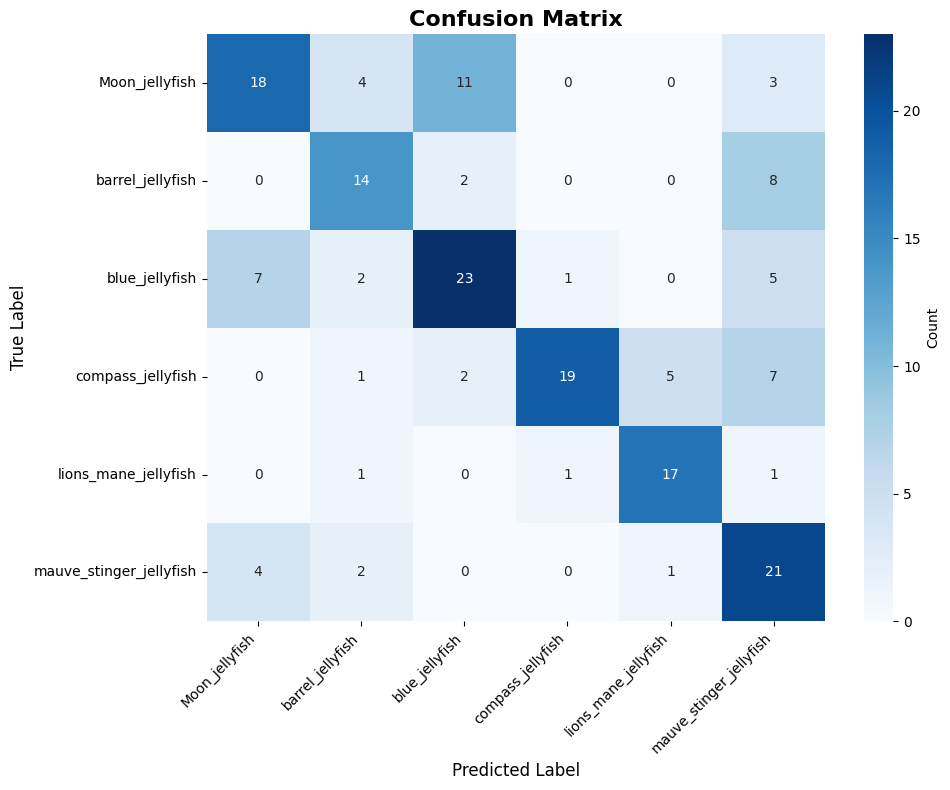


CONFUSION MATRIX STATISTICS
Total samples: 180
Correct predictions: 112
Incorrect predictions: 68
Overall Accuracy: 0.6222


In [34]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# Get predictions on validation set
y_true = []
y_pred = []

print("Generating predictions on validation set...")
for images, labels in val_ds:
    predictions = conv_model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Print Classification Report
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, y_pred, target_names=class_names))

# Create and plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Print confusion matrix statistics
print("\n" + "="*60)
print("CONFUSION MATRIX STATISTICS")
print("="*60)
print(f"Total samples: {np.sum(cm)}")
print(f"Correct predictions: {np.trace(cm)}")
print(f"Incorrect predictions: {np.sum(cm) - np.trace(cm)}")
print(f"Overall Accuracy: {np.trace(cm) / np.sum(cm):.4f}")